# STCS Tutorial: Spatial Transcriptomics Cell Segmentation

This tutorial is used torun the complete STCS pipeline based on the merged `STCS_main.py` module. 

This is an Example Notebook for **Visium HD** data specific. 

The pipeline includes:

1. **Data Preparation**: Loading and cropping spatial data

2. **Cell Segmentation**: Segmentation pipeline for nucleus detection

3. **Pseudobulk Creation**: Aggregating spots into cell-level data

4. **PCA Assignment**: Gene space assignment with reference data

5. **Cell Type Annotation**: CellTypist-based annotation

6. **Visualization**: Spatial plotting of results

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq


# Import the STCS module
sys.path.append("STCS")
from STCS_main import STCS 

# For visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import plot
from matplotlib.colors import ListedColormap
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

/home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lc1418/.conda/envs/spatial_analysis/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


# Set up paths

In [2]:
# Define data type: Visium
PLATFORM = "Visium"

# Folder containing filtered_feature_bc_matrix.h5 and the spatial/ folder
FOLDER_PATH = '/lab01/lc1418/ST/Visium_HD_Exp2/binned_outputs/square_002um'

# Paired full-resolution H&E image
FULL_RES_IMAGE_PATH = '/lab01/lc1418/Xenium_Prime_Human_Lung_Cancer_FFPE_he_image.ome.tif'

# Paired scRNA-seq reference (set to None if you do not have one)
SC_REF_PATH = '/home/lc1418/ST/scrnaref/a95f7e58_lung.h5ad'

# CellTypist model for cell-type annotation. Replace with a model trained on your own
# tissue, or annotate the reconstructed cells manually.
MODEL_PATH = '/home/lc1418/ST/scrnaref/celltypist_a95f7e58_author_cell_type_level_1.SYMBOLS.magli.hvg5k.pkl'

# ---- what to run ----
# True  : reconstruct the entire slide (hours, and tens of GB of output)
# False : reconstruct CROP_RECT only, which is the fast way to try the pipeline out
RUN_WHOLE_SLIDE = True
CROP_RECT = (1000, 18000, 3000, 3000)   # (x, y, w, h); ignored when running whole slide

# ---- the parameters chosen in Parameter_Tuning.ipynb ----
# These are slide-specific. Re-tune for a new section, platform or bin size.
SEARCH_RADIUS = 2     # S, in bins
LAMBDA = 0.5          # weight on the spatial term


In [3]:
# Everything the pipeline writes goes here. A whole-slide run produces tens of GB,
# so put this on a disk with room.
RESULTS_PATH = "/lab01/lc1418/ST/stcs_wholeslide_S2_L0.5"
os.makedirs(RESULTS_PATH, exist_ok=True)
print("writing to", RESULTS_PATH)


writing to /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5


# 1. Data Preparation and Loading

Start by loading the full spatial transcriptomics dataset and cropping a region of interest for faster processing.

## Load full data

In [4]:
# Load the full dataset
full_data = STCS(
    Folder_path=FOLDER_PATH,
    counts_data="filtered_feature_bc_matrix.h5",
    full_res_image_path=FULL_RES_IMAGE_PATH,
    sc_ref=SC_REF_PATH,
    model_path=MODEL_PATH,
    Platform = PLATFORM
)

[Log]: Loaded Visium data
[Log]: source_image_path set in metadata: /lab01/lc1418/Xenium_Prime_Human_Lung_Cancer_FFPE_he_image.ome.tif
[Log]: Found spatial info
[Log]: STCS loaded: 6535116 spots, 18085 genes


In [5]:
x1, x2, y1, y2 = full_data.get_sequencing_data_region()
print(f"Data region bounds: x=({x1}, {x2}), y=({y1}, {y2})")

Data region bounds: x=(-5810, 18456), y=(-316, 24480)


## Crop

In [6]:
# Whole slide, or one crop. The rest of the notebook is identical either way: it works
# on `crop_data`, which is the full object when RUN_WHOLE_SLIDE is True.

if RUN_WHOLE_SLIDE:
    crop_data = full_data
    print("Whole slide: {:,} bins".format(crop_data.adata.n_obs))
else:
    x, y, w, h = CROP_RECT
    print("Cropping ({}, {}) to ({}, {})".format(x, y, x + w, y + h))
    crop_data = full_data.crop(x, x + w, y, y + h, 1)
    if crop_data is None:
        raise RuntimeError("Cropping failed")

    crop_img = crop_data.load_img()
    plt.imshow(crop_img)
    spatial = crop_data.adata.obsm["spatial"]
    plt.scatter(spatial[:, 0], spatial[:, 1], s=0.05, c="red", alpha=0.5)
    plt.title("Cropped image with bin coordinates")
    plt.axis("off")
    plt.show()


Whole slide: 6,535,116 bins


## Display the cropped H&E image

In [7]:
# The full-resolution H&E is several GB, so only display it for a crop.
if not RUN_WHOLE_SLIDE:
    plt.imshow(crop_data.load_img())
    plt.axis("off")
    plt.show()


## Save the cropped data

In [8]:
crop_data.save(RESULTS_PATH)

... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


[Log]: STCS data saved to /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5


# 2. Cell Segmentation

Next, we perform cell segmentation

In [9]:
# load the cropped data so that we could skip the cropping step in future runs
crop_data = STCS.from_saved(RESULTS_PATH)

[Log]: STCS loaded raw data from /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5: 6535116 spots, 18085 genes


## Segmentation

In [10]:
crop_data_segmented = crop_data.run_stardist_pipeline(
    RESULTS_PATH,
    prob_thresh=0.1,
    factor = 1)

[Log]: Starting stardist pipeline
[Debug]: has cropped_img? True
[Debug]: cropped_img is None? True
[Debug]: cropped_img shape: None
[Log]: Loaded full image | Shape: (43270, 26720, 3) | Dtype: uint8


2026-10-07 21:50:05.435885: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-07 21:50:05.470134: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


100%|██████████| 16/16 [01:51<00:00,  6.97s/it]


In [11]:
# Nucleus labels over the H&E. Only meaningful for a crop: `cropped_img` is not set
# when running the whole slide, and a slide-wide scatter is unreadable anyway.
if not RUN_WHOLE_SLIDE and getattr(crop_data_segmented, "cropped_img", None) is not None:
    coords = crop_data_segmented.adata.obsm["spatial"]
    labels = crop_data_segmented.adata.obs["labels_he"].astype(int).values
    mask = labels != 0

    plt.figure(figsize=(8, 8))
    plt.imshow(crop_data_segmented.cropped_img)
    plt.scatter(coords[mask, 0], coords[mask, 1], c="blue", s=1, linewidth=0, alpha=0.8)
    plt.axis("off")
    plt.title("StarDist nucleus labels on H&E")
    plt.show()

labels_all = crop_data_segmented.adata.obs["labels_he"].astype(int)
print("bins inside a nucleus: {:,} / {:,}   ({:,} nuclei)".format(
    int((labels_all != 0).sum()), crop_data_segmented.adata.n_obs,
    labels_all[labels_all != 0].nunique()))


bins inside a nucleus: 1,116,801 / 6,535,116   (163,439 nuclei)


In [12]:
crop_data_segmented.save(RESULTS_PATH)

[Log]: STCS data saved to /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5


# 3. Pseudobulk Generation

We create pseudobulk data by aggregating gene expression from spots assigned to the same cell.

In [13]:
# load the cropped data so that we could skip the cropping step in future runs
crop_data_segmented = STCS.from_saved(RESULTS_PATH)

[Log]: STCS loaded raw data from /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5: 6535116 spots, 18085 genes


In [14]:
crop_data_with_pseudobulk = crop_data_segmented.create_pseudobulk_from_stardist(
    output_path=RESULTS_PATH,
    mode='mean',
)

[Log]: Starting pseudobulk creation from stardist results
[Log]: Loading stardist barcode data
[Log]: Processing 6535116 common barcodes


Assigning labels_he: 100%|██████████| 66/66 [00:07<00:00,  8.76chunk/s]


[Log]: Assigned labels to 6535116 cells
[Log]: Creating pseudobulk based on labels_he
[Log]: pseudobulk over 1116801/6535116 bins (163439 cells)
[Log]: Found 163439 unique groups
[Log]: Starting vectorized mean aggregation...
[Log]: Creating final pseudobulk object...
[Log]: Successfully created pseudobulk with 163439 cells and 18085 genes
[Log]: Pseudobulk creation completed
[Log]: Results saved to /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5/pseudobulk


In [15]:
crop_data_with_pseudobulk

In [16]:
crop_data_with_pseudobulk.save(RESULTS_PATH)

[Log]: STCS data saved to /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5


# 5. PCA-based Assignment

We perform gene space assignment using PCA to match barcodes to cells based on transcriptomic similarity.

In [17]:
crop_data_with_pseudobulk = STCS.from_saved(RESULTS_PATH)

[Log]: STCS loaded raw data from /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5: 6535116 spots, 18085 genes


In [18]:
# S and lambda come from Parameter_Tuning.ipynb; they are set at the top of this notebook.
print("Assigning bins with S={}, lambda={}".format(SEARCH_RADIUS, LAMBDA))

crop_data_assigned = crop_data_with_pseudobulk.run_assignment(
    output_path=RESULTS_PATH,
    use_sc_ref=True,            # use the single-cell reference if one was given
    search_radius=SEARCH_RADIUS,
    L=LAMBDA,
    normalize_distances=True,   # normalise the transcriptomic distances
    feature_name=True,          # the sc reference uses feature names, not gene symbols
)


Assigning bins with S=2, lambda=0.5
[Log]: Starting assignment pipeline based on candidate search + PCA processing + gene space assignment 
[Log]: Creating barcode to candidate cells mapping
[Log]: Creating barcode candidates mapping with precomputed circle offsets
[Log]: Processed 0/6535116 barcodes
[Log]: Processed 500000/6535116 barcodes
[Log]: Processed 1000000/6535116 barcodes
[Log]: Processed 1500000/6535116 barcodes
[Log]: Processed 2000000/6535116 barcodes
[Log]: Processed 2500000/6535116 barcodes
[Log]: Processed 3000000/6535116 barcodes
[Log]: Processed 3500000/6535116 barcodes
[Log]: Processed 4000000/6535116 barcodes
[Log]: Processed 4500000/6535116 barcodes
[Log]: Processed 5000000/6535116 barcodes
[Log]: Processed 5500000/6535116 barcodes
[Log]: Processed 6000000/6535116 barcodes
[Log]: Processed 6500000/6535116 barcodes
[Log]: Created candidates mapping for 6535116 barcodes
[Log]: Candidates mapping saved to: /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5/integrated_assignment

Final assignment: 100%|██████████| 6535116/6535116 [00:07<00:00, 864305.39it/s] 


[Log]: Assigned 3432459 barcodes
[Log]: Saving integrated assignment results
[Log]: Assignment is done
[Log]: Results saved to /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5/integrated_assignment


# 6. Cell Type Annotation with CellTypist

We annotate the assigned cells using CellTypist to predict cell types based on gene expression.

In [19]:
crop_data_annotated = crop_data_assigned.run_celltypist_annotation(
    output_path=RESULTS_PATH,
    train_celltypist_model=False
)

[Log]: Starting CellTypist annotation pipeline
[Log]: Creating pseudobulk for CellTypist
[Log]: Starting pseudobulk creation from assignment results
[Log]: Creating pseudobulk based on assigned_cell_id
[Log]: pseudobulk over 3432459/6535116 bins (163439 cells)
[Log]: Found 163439 unique groups
[Log]: Starting vectorized sum aggregation...
[Log]: Creating final pseudobulk object...
[Log]: Successfully created pseudobulk with 163439 cells and 18085 genes
[Log]: Pseudobulk creation completed
[Log]: Results saved to /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5/pseudobulk
[Log]: Running CellTypist annotation


🔬 Input data has 163439 cells and 18085 genes
🔗 Matching reference genes in the model


[Log]: Using model: /home/lc1418/ST/scrnaref/celltypist_a95f7e58_author_cell_type_level_1.SYMBOLS.magli.hvg5k.pkl


🧬 3677 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 25
🗳️ Majority voting the predictions
✅ Majority voting done!


[Log]: Saving annotated results
[Log]: Merging back column: predicted_labels
[Log]: Merging back column: over_clustering
[Log]: Merging back column: majority_voting
[Log]: Merging back column: conf_score


... storing 'assigned_cell_id' as categorical
... storing 'celltypist_predicted_labels' as categorical
... storing 'celltypist_over_clustering' as categorical
... storing 'celltypist_majority_voting' as categorical
... storing 'celltypist_conf_score' as categorical


[Log]: CellTypist annotation completed
[Log]: Results saved to /lab01/lc1418/ST/stcs_wholeslide_S2_L0.5/celltypist_annotation


# 7. Visualization

We create spatial visualizations of the annotated cell types.

In [20]:
annotated_adata = crop_data_annotated.adata.copy()

In [21]:
annotated_adata.obs

,in_tissue,array_row,array_col,labels_he,assigned_cell_id,celltypist_predicted_labels,celltypist_over_clustering,celltypist_majority_voting,celltypist_conf_score
s_002um_02448_01644-1,1,2448,1644,0,None,undefined,undefined,undefined,undefined
s_002um_00700_02130-1,1,700,2130,0,166445,T.CD4,296,T.CD4,0.09657579940095765
s_002um_02703_00756-1,1,2703,756,0,159939,Fibroblast,429,Fibroblast,0.1382441175518264
s_002um_02043_00141-1,1,2043,141,0,None,undefined,undefined,undefined,undefined
s_002um_02278_00850-1,1,2278,850,63746,63746,cDC,287,T.CD4,0.1502283809172308
...,...,...,...,...,...,...,...,...,...
s_002um_02189_01783-1,1,2189,1783,0,131012,T.CD8,880,T.CD4,0.12920862335197436
s_002um_01609_01578-1,1,1609,1578,0,None,undefined,undefined,undefined,undefined
s_002um_03010_00102-1,1,3010,102,0,135051,T.CD4,79,Fibroblast,0.3772765676935226
s_002um_00456_02202-1,1,456,2202,176490,176490,T.CD4,180,T.CD8,0.1676534861579924


In [22]:
# fill nan with filtered
annotated_adata.obs["celltypist_predicted_labels"] = annotated_adata.obs["celltypist_predicted_labels"].astype('str')
annotated_adata.obs["celltypist_predicted_labels"] = annotated_adata.obs["celltypist_predicted_labels"].replace("nan", "undefined")
annotated_adata = annotated_adata[annotated_adata.obs["celltypist_predicted_labels"] != 'undefined']

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import MultiPoint
from shapely import concave_hull
import colorsys

USE_CONCAVE_HULL = True
CONCAVE_RATIO = 0.3
DARKEN_FACTOR = 0.4
BOUNDARY_LINEWIDTH = 0.6
BOUNDARY_ALPHA = 0.9

def darken_color(hex_color, factor=0.4):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = l * factor
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mpl.colors.to_hex([r, g, b])

def get_cell_boundary(points):
    if len(points) < 3:
        return None
    mp = MultiPoint(points)
    if USE_CONCAVE_HULL:
        hull = concave_hull(mp, ratio=CONCAVE_RATIO)
    else:
        hull = mp.convex_hull

    if hull.is_empty or hull.geom_type in ("Point", "LineString"):
        hull = mp.convex_hull

    if hull.geom_type == "Polygon":
        return np.array(hull.exterior.coords)
    return None

def _clean_series_str(s):
    """Return a string series where NaN-like values are set to <NA>."""
    s = s.astype("string")
    # treat these as missing too
    bad = s.isna() | (s.str.strip() == "") | (s.str.lower().isin(["nan", "none", "null"]))
    s = s.mask(bad)
    return s

def plot_bins_with_cell_boundaries(
    adata_bins,
    cell_id_col="cell_id",
    label_col="celltypist_predicted_labels",
    invert_y=True,
    s=2,
    alpha=1.0,
    seed=0,
    min_points_for_boundary=3,  # only draw boundary if a cell has >= this many points
):
    # ---- validate columns ----
    if cell_id_col not in adata_bins.obs.columns:
        raise KeyError(f"obs['{cell_id_col}'] not found")
    if label_col not in adata_bins.obs.columns:
        raise KeyError(f"obs['{label_col}'] not found")
    if "spatial" not in adata_bins.obsm:
        raise KeyError("obsm['spatial'] not found")

    # ---- clean + filter BOTH cell_id and label ----
    cell_id_s = _clean_series_str(adata_bins.obs[cell_id_col])
    label_s   = _clean_series_str(adata_bins.obs[label_col])

    keep = cell_id_s.notna() & label_s.notna()
    ad = adata_bins[keep].copy()

    # re-attach cleaned strings (avoid lingering 'nan' strings)
    ad.obs[cell_id_col] = cell_id_s[keep].astype(str).values
    ad.obs[label_col]   = label_s[keep].astype(str).values

    if ad.n_obs == 0:
        raise ValueError("After filtering NaNs in cell_id and label, no observations remain.")

    # ---- coords ----
    xy = ad.obsm["spatial"]
    x = xy[:, 0]
    y = xy[:, 1]

    # ---- colors from remaining classes ----
    classes = sorted(ad.obs[label_col].astype(str).unique())
    rng = np.random.default_rng(seed)
    class_colors = {c: "#{:02x}{:02x}{:02x}".format(*rng.integers(0, 255, 3)) for c in classes}

    point_colors = ad.obs[label_col].astype(str).map(class_colors).values

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.scatter(x, y, c=point_colors, s=s, alpha=alpha,
               linewidths=0, marker="s", rasterized=True, zorder=1)

    # ---- boundaries per cell ----
    cell_ids = ad.obs[cell_id_col].astype(str).values
    labels   = ad.obs[label_col].astype(str).values

    order = np.argsort(cell_ids)
    cell_ids_sorted = cell_ids[order]
    x_sorted = x[order]
    y_sorted = y[order]
    labels_sorted = labels[order]

    start = 0
    while start < len(cell_ids_sorted):
        cid = cell_ids_sorted[start]
        end = start + 1
        while end < len(cell_ids_sorted) and cell_ids_sorted[end] == cid:
            end += 1

        npts = end - start
        if npts >= min_points_for_boundary:
            pts = np.column_stack([x_sorted[start:end], y_sorted[start:end]])
            ct = labels_sorted[start]
            boundary = get_cell_boundary(pts.tolist())
            if boundary is not None and len(boundary) >= 3:
                base = class_colors.get(ct, "#808080")
                edge = darken_color(base, DARKEN_FACTOR)
                ax.plot(boundary[:, 0], boundary[:, 1],
                        linewidth=BOUNDARY_LINEWIDTH, alpha=BOUNDARY_ALPHA,
                        color=edge, zorder=2)

        start = end

    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([]); ax.axis("off")
    if invert_y:
        ax.invert_yaxis()

    # ---- legend (only classes that survived filtering) ----
    handles = [
        mpl.lines.Line2D([0], [0], marker="o", color="none",
                         markerfacecolor=class_colors[c], markersize=8, label=c)
        for c in classes
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left",
              frameon=False, title="Cell type")

    plt.tight_layout()
    plt.show()


Showing 117,237 bins in the window (1000, 18000, 3000, 3000)


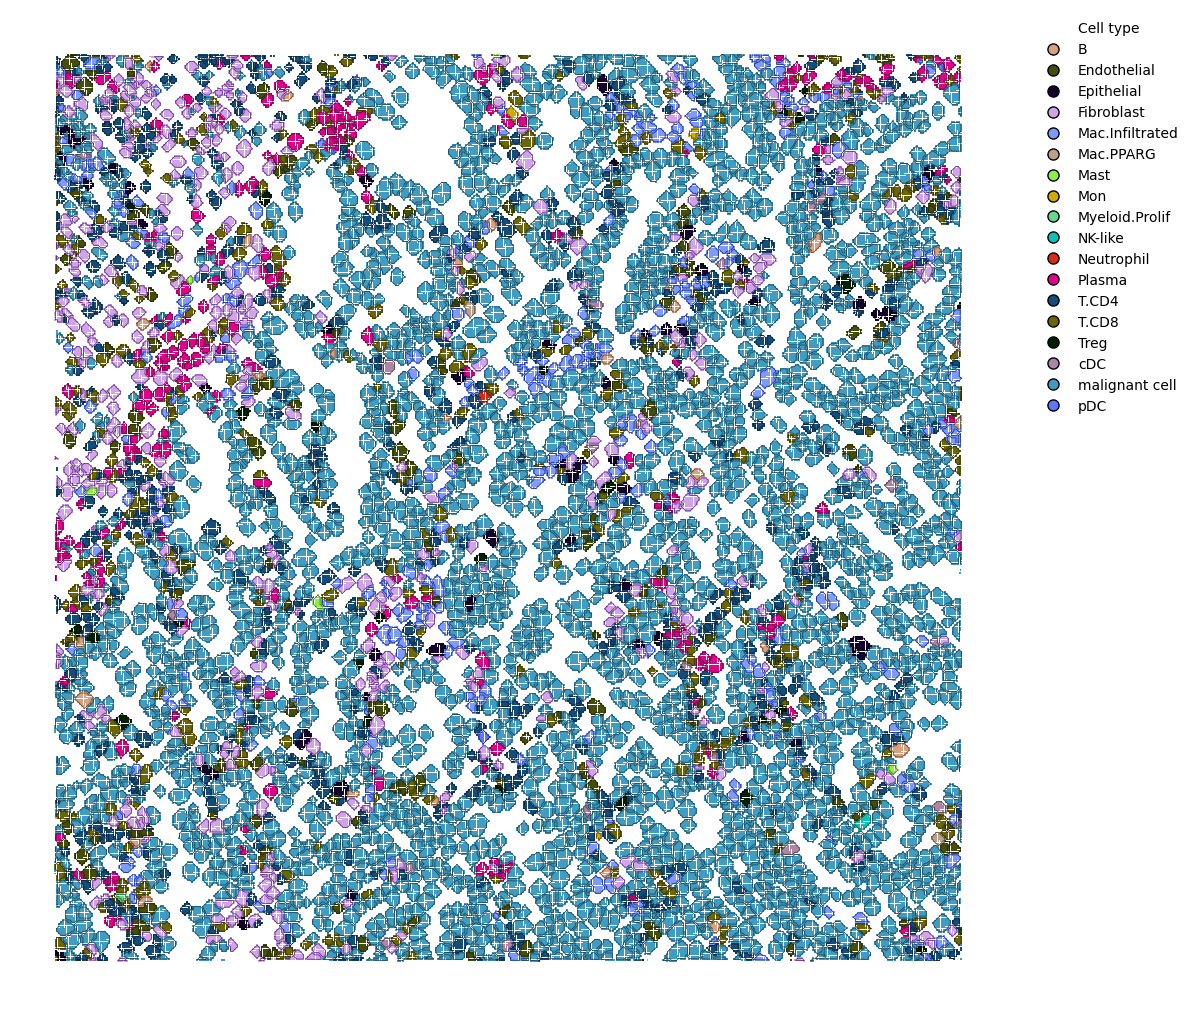

In [24]:
# Drawing a concave hull per cell is fine for a crop but not for a whole slide, where
# there are >100k cells and the figure would be both slow and unreadable. Zoom into a
# window instead; change VIEW to look somewhere else.
VIEW = (1000, 18000, 3000, 3000)   # (x, y, w, h) in full-resolution pixels

adata = annotated_adata
if RUN_WHOLE_SLIDE:
    x, y, w, h = VIEW
    xy = adata.obsm["spatial"]
    keep = ((xy[:, 0] >= x) & (xy[:, 0] < x + w) &
            (xy[:, 1] >= y) & (xy[:, 1] < y + h))
    adata = adata[keep].copy()
    print("Showing {:,} bins in the window {}".format(adata.n_obs, VIEW))

plot_bins_with_cell_boundaries(
    adata, cell_id_col="assigned_cell_id", label_col="celltypist_predicted_labels"
)
